# Module 5: Advanced ML Techniques

---

## 5.1 Imbalanced Data Handling
## 5.2 Feature Engineering
## 5.4 Explainability

---

# 5.1 Imbalanced Data Handling

## What is Class Imbalance?

**Definition:** A dataset is *imbalanced* when one class has significantly more samples than another.

```
Balanced Dataset:          Imbalanced Dataset:
  Class 0: ████████ 50%     Class 0: ████████████████ 95%
  Class 1: ████████ 50%     Class 1: █ 5%
```

**Real-world examples:**
- Fraud detection: 0.1% fraudulent transactions vs 99.9% normal
- Disease diagnosis: 5% sick patients vs 95% healthy
- Spam detection: 10% spam vs 90% legitimate email

## Why Is It a Problem?

A model trained on 95% Class 0 and 5% Class 1 can achieve **95% accuracy by just predicting Class 0 every time!**

```
Lazy model predicts: "Not Fraud" for EVERYTHING
Accuracy = 9500/10000 = 95%  ← looks great, IS USELESS
```

We need **Recall, Precision, F1, AUC-ROC** instead of accuracy.

---
## 5.1.1 SMOTE (Synthetic Minority Oversampling TEchnique)

### Definition
SMOTE creates **synthetic (fake but realistic) samples** of the minority class by interpolating between existing minority samples.

### Simple Analogy
> Imagine you have only 5 photos of cats and 100 photos of dogs. SMOTE creates new cat photos by blending features of two existing cat photos — not duplicating, but creating plausible new ones.

### How It Works — Step by Step

```
Step 1: Pick a minority sample (e.g., a fraud transaction)
        Point A: [amount=500, hour=2, location=NYC]

Step 2: Find its K nearest neighbors in the minority class
        Point B: [amount=480, hour=3, location=NYC]  ← neighbor

Step 3: Create a synthetic point on the line between A and B
        Synthetic = A + random(0,1) × (B - A)
        Example:  = [500 + 0.5×(480-500), 2 + 0.5×(3-2), NYC]
                  = [490, 2.5, NYC]   ← NEW synthetic fraud sample
```

### Math
$$x_{new} = x_i + \lambda \times (x_{nn} - x_i)$$

Where:
- $x_i$ = selected minority sample
- $x_{nn}$ = a random nearest neighbor of $x_i$
- $\lambda$ = random number between 0 and 1

**Simple example:**
- Point A = 10, Point B = 20, λ = 0.3
- New point = 10 + 0.3 × (20 - 10) = **13**  (between A and B)

### Diagram
```
Feature 2
  |
5 |    ○ B
  |   /
3 |  ★ ← synthetic point created here
  | /
1 |○ A
  +------------- Feature 1
  1    3    5

○ = original minority samples
★ = SMOTE-generated synthetic sample
```

### When to Use
- Binary or multi-class classification with imbalance ratio > 4:1
- When you have enough minority samples to interpolate (at least ~20+)
- Tabular data (works best; not ideal for images/text directly)

### When NOT to Use
- When minority class has too few samples (<10) — interpolation is meaningless
- When classes overlap heavily — synthetic points may fall in wrong region
- For tree-based models with class weights available (class weights often work just as well)

### Variants
| Variant | What it does |
|---|---|
| SMOTE | Basic interpolation |
| SMOTE-Tomek | SMOTE + remove borderline majority samples |
| SMOTE-ENN | SMOTE + clean noisy samples with Edited Nearest Neighbors |
| ADASYN | Generates more samples near harder-to-learn boundary |
| Borderline-SMOTE | Focus only on samples near decision boundary |

=== Original Class Distribution ===
Class counts: Counter({0: 1892, 1: 108})
Imbalance ratio: 17.5:1

=== After SMOTE ===
Class counts: Counter({0: 1892, 1: 1892})
New total samples: 3784 (was 2000)


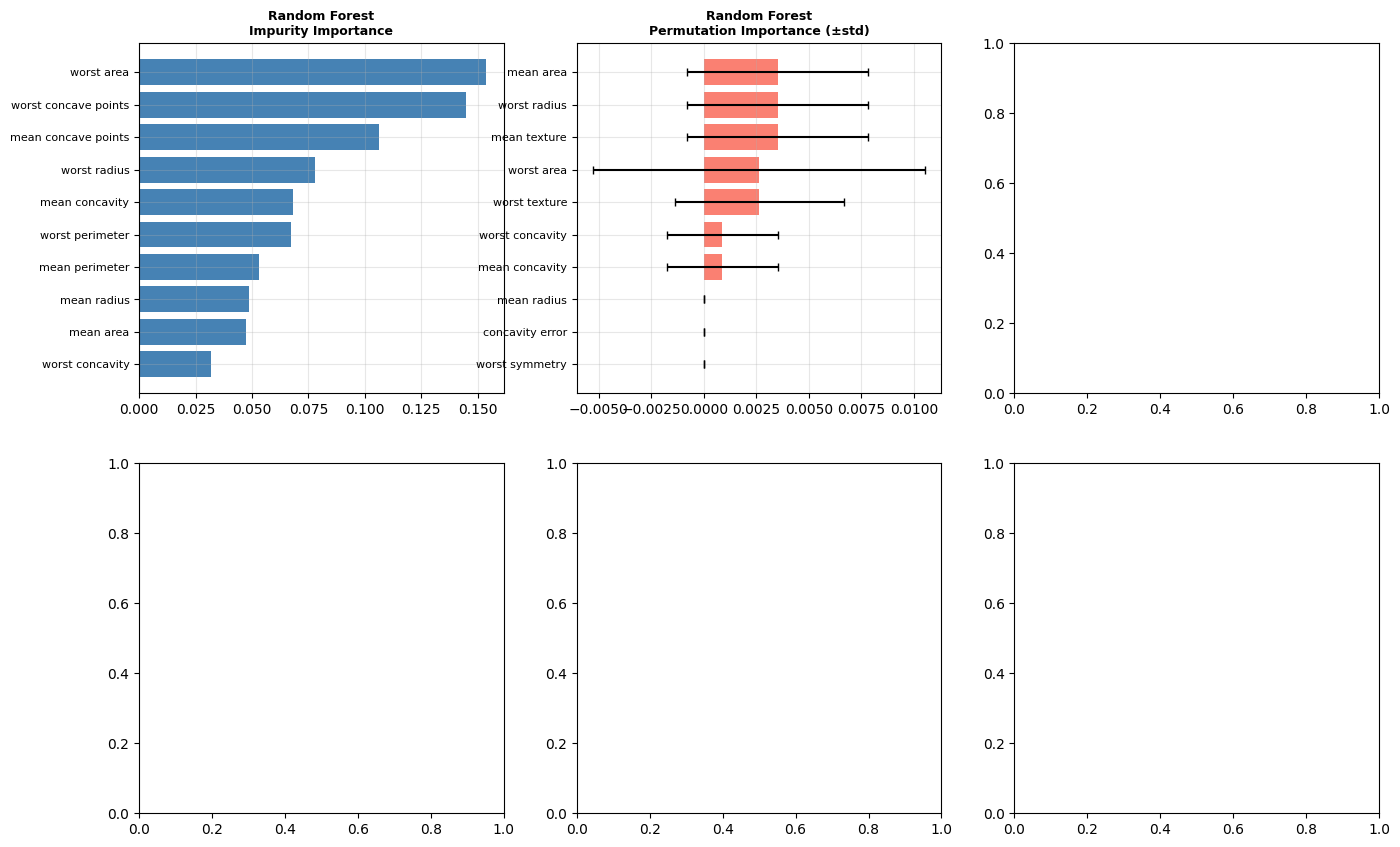

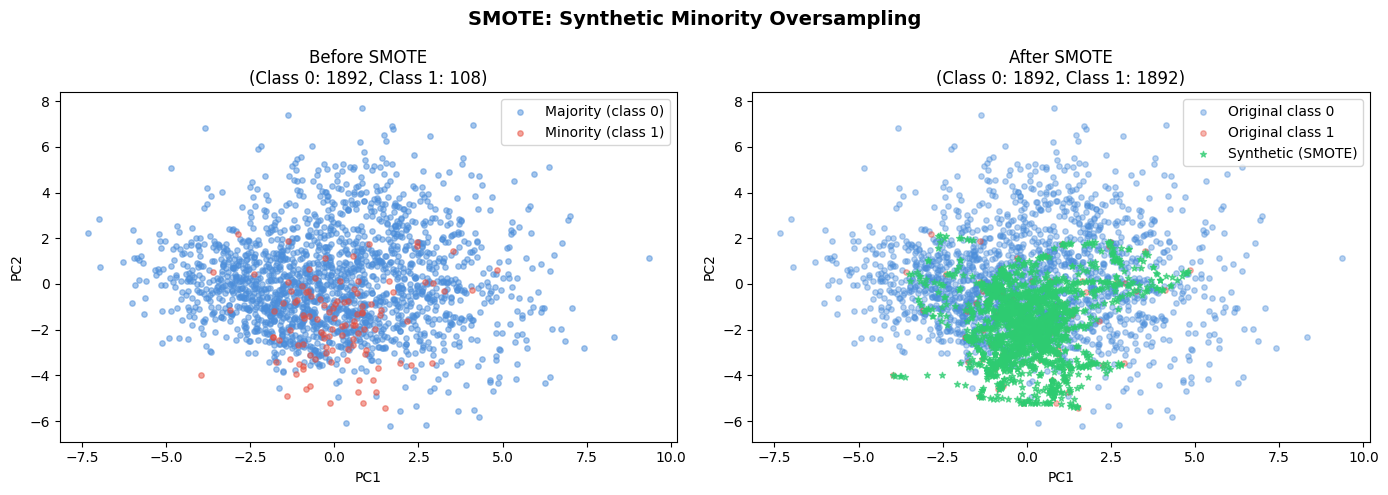

In [23]:
# ── SMOTE Demo ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from collections import Counter

# Create imbalanced dataset: 95% class 0, 5% class 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_informative=5,
    weights=[0.95, 0.05], random_state=42
)

print("=== Original Class Distribution ===")
print(f"Class counts: {Counter(y)}")
print(f"Imbalance ratio: {Counter(y)[0]/Counter(y)[1]:.1f}:1")

# Apply SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("\n=== After SMOTE ===")
print(f"Class counts: {Counter(y_smote)}")
print(f"New total samples: {len(y_smote)} (was {len(y)})")

# Visualize with 2D PCA projection
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
X_smote_2d = pca.transform(X_smote)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {0: '#4C8EDA', 1: '#E74C3C'}
labels = {0: 'Majority (class 0)', 1: 'Minority (class 1)'}

for cls in [0, 1]:
    mask = y == cls
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[cls], label=labels[cls], alpha=0.5, s=15)
ax1.set_title(f'Before SMOTE\n(Class 0: {Counter(y)[0]}, Class 1: {Counter(y)[1]})',
               fontsize=12)
ax1.legend()
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

# Show original + synthetic separately
n_orig = len(y)
for cls in [0, 1]:
    mask_orig = (y_smote[:n_orig] == cls)
    ax2.scatter(X_smote_2d[:n_orig][mask_orig, 0],
                X_smote_2d[:n_orig][mask_orig, 1],
                c=colors[cls], alpha=0.4, s=15, label=f'Original class {cls}')
# Synthetic samples (added after original)
ax2.scatter(X_smote_2d[n_orig:, 0], X_smote_2d[n_orig:, 1],
            c='#2ECC71', alpha=0.7, s=20, marker='*', label='Synthetic (SMOTE)')
ax2.set_title(f'After SMOTE\n(Class 0: {Counter(y_smote)[0]}, Class 1: {Counter(y_smote)[1]})',
               fontsize=12)
ax2.legend()
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

plt.suptitle('SMOTE: Synthetic Minority Oversampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# ── Compare model performance: No resampling vs SMOTE ──────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Apply SMOTE only on training data
X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)

results = {}
for name, Xtr, ytr in [
    ('No resampling', X_train, y_train),
    ('With SMOTE',    X_train_smote, y_train_smote),
]:
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(Xtr, ytr)
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f" {name}")
    print('='*40)
    print(classification_report(y_test, y_pred, target_names=['Majority','Minority']))


 No resampling
              precision    recall  f1-score   support

    Majority       0.95      1.00      0.97       568
    Minority       0.33      0.03      0.06        32

    accuracy                           0.94       600
   macro avg       0.64      0.51      0.51       600
weighted avg       0.92      0.94      0.92       600


 With SMOTE
              precision    recall  f1-score   support

    Majority       0.98      0.75      0.85       568
    Minority       0.14      0.69      0.23        32

    accuracy                           0.75       600
   macro avg       0.56      0.72      0.54       600
weighted avg       0.93      0.75      0.82       600



---
## 5.1.2 Class Weights

### Definition
**Class weights** tell the model to *penalize mistakes on the minority class more heavily*. Instead of adding/removing data, we change how much each sample contributes to the loss function.

### Simple Analogy
> In a class of 95 students who passed and 5 who failed, if you grade an exam and miss a failed student, you're penalized **19× more** than if you miss a passed student. This forces the model to pay more attention to the rare class.

### Math

**Weighted Loss:**
$$\text{Loss} = \sum_i w_{y_i} \cdot \ell(y_i, \hat{y}_i)$$

Where $w_{y_i}$ is the weight for class $y_i$.

**`class_weight='balanced'` formula:**
$$w_j = \frac{n_{\text{total}}}{n_{\text{classes}} \times n_j}$$

**Simple example:**
- 1000 total samples: 950 Class 0, 50 Class 1
- $w_0 = \frac{1000}{2 \times 950} = 0.526$
- $w_1 = \frac{1000}{2 \times 50} = 10.0$
- Every Class 1 mistake counts **~19× more** than a Class 0 mistake

### Diagram
```
Standard Loss:            Weighted Loss:
Each wrong prediction     Missing a minority sample
= 1 unit of penalty       = 19 units of penalty!

Model learns:             Model learns:
"Predict majority         "Be careful about
 most of the time"         the minority class!"
```

> **Are 1 unit and 19 units fixed?**
> **No — the penalty ratio always equals your class imbalance ratio.**
> It is calculated from the `class_weight='balanced'` formula:
> $w_j = \frac{n_{\text{total}}}{n_{\text{classes}} \times n_j}$

| Dataset ratio (0:1) | $w_0$ | $w_1$ | Penalty ratio |
|---|---|---|---|
| 50:50 (balanced) | 1.0 | 1.0 | **1×** (equal) |
| 80:20 | 0.625 | 2.5 | **4×** |
| 90:10 | 0.556 | 5.0 | **9×** |
| 95:5 (our example) | 0.526 | 10.0 | **19×** |
| 99:1 | 0.505 | 50.0 | **99×** |

**Rule of thumb:** penalty ratio ≈ imbalance ratio.
If minority is 19× rarer → each mistake costs 19× more.
If minority is 99× rarer → each mistake costs 99× more.

### When to Use
- Tree-based models (XGBoost, LightGBM, Random Forest) — very natural fit
- Logistic Regression, SVM
- When you want simplicity (no data augmentation needed)
- When SMOTE would create too many noisy synthetic samples

### Pros vs Cons
| Pros | Cons |
|---|---|
| No data modification | Doesn't add information |
| Works with any sklearn estimator | Requires model to support `class_weight` |
| Fast — no extra computation | Less effective for extreme imbalance (>100:1) |
| Interpretable | |

Class 0 weight: 0.5287
Class 1 weight: 9.2105
Weight ratio (w1/w0): 17.4x

=== Performance Comparison ===
                       Accuracy  Precision  Recall     F1
Model                                                    
No weight                 0.945      0.333   0.031  0.057
class_weight=balanced     0.725      0.133   0.750  0.225
RF balanced               0.958      1.000   0.219  0.359

→ Notice: Accuracy may drop slightly but Recall improves significantly


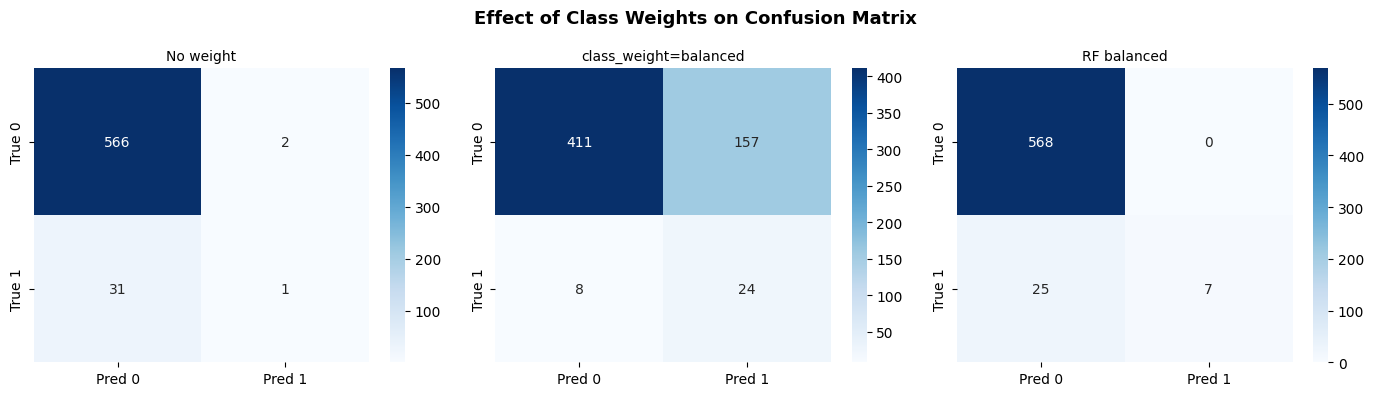

In [25]:
# ── Class Weights Demo ──────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score, precision_score
import pandas as pd

# Compute balanced weights manually
n_total = len(y_train)
n_classes = 2
n_0 = np.sum(y_train == 0)
n_1 = np.sum(y_train == 1)
w_0 = n_total / (n_classes * n_0)
w_1 = n_total / (n_classes * n_1)
print(f"Class 0 weight: {w_0:.4f}")
print(f"Class 1 weight: {w_1:.4f}")
print(f"Weight ratio (w1/w0): {w_1/w_0:.1f}x")

configs = [
    ('No weight',           LogisticRegression(max_iter=1000, random_state=42)),
    ('class_weight=balanced', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('RF balanced',         RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
]

rows = []
for name, model in configs:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rows.append({
        'Model': name,
        'Accuracy':  round(np.mean(y_pred == y_test), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'F1':        round(f1_score(y_test, y_pred), 3),
    })

df = pd.DataFrame(rows).set_index('Model')
print("\n=== Performance Comparison ===")
print(df.to_string())
print("\n→ Notice: Accuracy may drop slightly but Recall improves significantly")

# Visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
import seaborn as sns

for ax, (name, model) in zip(axes, configs):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    ax.set_title(name, fontsize=10)

plt.suptitle('Effect of Class Weights on Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5.1.3 Threshold Tuning

### Definition
Most classifiers output a **probability** (e.g., 0.73 = 73% chance of fraud). The **decision threshold** is the cutoff used to convert that probability into a class label.

Default: `if P(fraud) >= 0.5 → predict fraud`

Threshold tuning: `if P(fraud) >= 0.3 → predict fraud`  (lower threshold = more sensitive)

### Simple Analogy
> A smoke alarm has a sensitivity dial. Turn it up (lower threshold) and it triggers on light smoke — fewer missed fires, but more false alarms. Turn it down (higher threshold) — fewer false alarms, but you might miss a real fire. **Choose the dial setting based on what error is more costly.**

### Trade-off Diagram
```
              LOW THRESHOLD (e.g. 0.1)      HIGH THRESHOLD (e.g. 0.9)
              ────────────────────────      ──────────────────────────
Recall        HIGH  (catch most fraud)      LOW  (miss many frauds)
Precision     LOW   (many false alarms)     HIGH (very few false alarms)
Use when      Missing fraud is costly       False alarm is costly
              (medical diagnosis)           (spam filter)

         Threshold ──────────────────────────────────────────→
         0.1       0.3       0.5       0.7       0.9
Recall   ████████████████████████████████░░░░░░░░░░░
Precis.  ░░░░░░░░░░░░░░░░░░░░░░████████████████████
F1       ░░░░░░░░████████████████████████░░░░░░░░░░
                              ↑ sweet spot
```

### Key Curves
- **ROC Curve:** Plots True Positive Rate vs False Positive Rate at all thresholds
- **Precision-Recall Curve:** Plots Precision vs Recall at all thresholds (better for imbalanced data)

### When to Use
- After training a model, to optimize the operating point
- When the cost of false positives ≠ cost of false negatives
- Fraud detection, medical screening (minimize false negatives)
- Spam filters (minimize false positives)

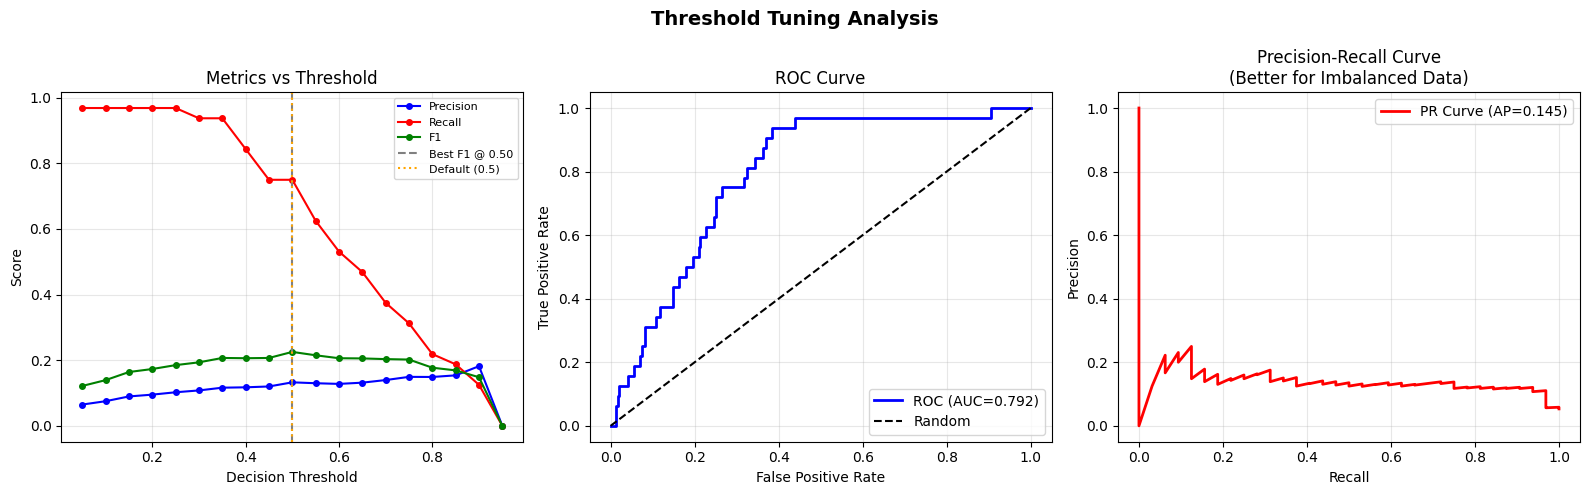


Default threshold (0.5): F1=0.225
Optimal threshold (0.50): F1=0.225


In [26]:
# ── Threshold Tuning Demo ───────────────────────────────────
from sklearn.metrics import (roc_curve, precision_recall_curve,
                              roc_auc_score, average_precision_score)

# Train model with balanced weights
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1

# ── Plot 1: Effect of threshold on metrics ──
thresholds = np.arange(0.05, 0.96, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    # guard against divide-by-zero
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    precisions.append(p); recalls.append(r); f1s.append(f)

best_t = thresholds[np.argmax(f1s)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Threshold vs Metrics
ax = axes[0]
ax.plot(thresholds, precisions, 'b-o', ms=4, label='Precision')
ax.plot(thresholds, recalls,    'r-o', ms=4, label='Recall')
ax.plot(thresholds, f1s,        'g-o', ms=4, label='F1')
ax.axvline(best_t, color='gray', linestyle='--', label=f'Best F1 @ {best_t:.2f}')
ax.axvline(0.5, color='orange', linestyle=':', label='Default (0.5)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ROC Curve
fpr, tpr, roc_thresh = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
ax = axes[1]
ax.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend(); ax.grid(True, alpha=0.3)

# Precision-Recall Curve
prec, rec, pr_thresh = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
ax = axes[2]
ax.plot(rec, prec, 'r-', lw=2, label=f'PR Curve (AP={ap:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve\n(Better for Imbalanced Data)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Threshold Tuning Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDefault threshold (0.5): F1={f1s[np.argmin(np.abs(thresholds-0.5))]:.3f}")
print(f"Optimal threshold ({best_t:.2f}): F1={max(f1s):.3f}")

---
# 5.2 Feature Engineering

## What is Feature Engineering?

**Definition:** The process of using domain knowledge and statistical techniques to select, transform, and create input variables (features) that make machine learning models perform better.

> "In machine learning, the data and features you feed the model matter far more than which algorithm you choose." — Andrew Ng

```
Raw Data → Feature Engineering → Better Features → Better Model

Raw:  [date: 2024-03-15 14:30, city: NYC, price: 250]
      ↓ engineer
Good: [hour=14, is_weekend=0, is_rush_hour=1, city_avg_price=320,
       price_vs_avg=-70, day_of_week=4]
```

---
## 5.2.1 Feature Selection

### Definition
Feature selection is the process of **choosing a subset of the most relevant features** and discarding irrelevant or redundant ones.

### Why It's Needed
```
Too many features → Curse of Dimensionality:
  - Overfitting (model memorizes noise)
  - Slow training
  - Hard to interpret
  - Some models degrade with irrelevant features
```

### Methods Overview

```
Feature Selection Methods
│
├── Filter Methods (score each feature independently)
│   ├── Correlation with target
│   ├── Chi-squared test (categorical)
│   ├── ANOVA F-test (numerical vs categorical target)
│   └── Mutual Information
│
├── Wrapper Methods (use model to evaluate subsets)
│   ├── Forward Selection (add features one by one)
│   ├── Backward Elimination (remove features one by one)
│   └── Recursive Feature Elimination (RFE)
│
└── Embedded Methods (feature selection during training)
    ├── Lasso (L1 regularization drives weak weights to 0)
    ├── Ridge (L2 — shrinks but doesn't zero out)
    └── Tree feature importance
```

### Simple Example
Predicting house price:
- **Relevant:** square footage, location, bedrooms
- **Irrelevant:** owner's name, listing ID
- **Redundant:** both `area_sqft` and `area_sqm` (same info twice)

### When to Use
- When you have many features (>20) and want to reduce dimensionality
- When training is slow due to too many features
- When you need interpretable models

Dataset: 569 samples, 30 features


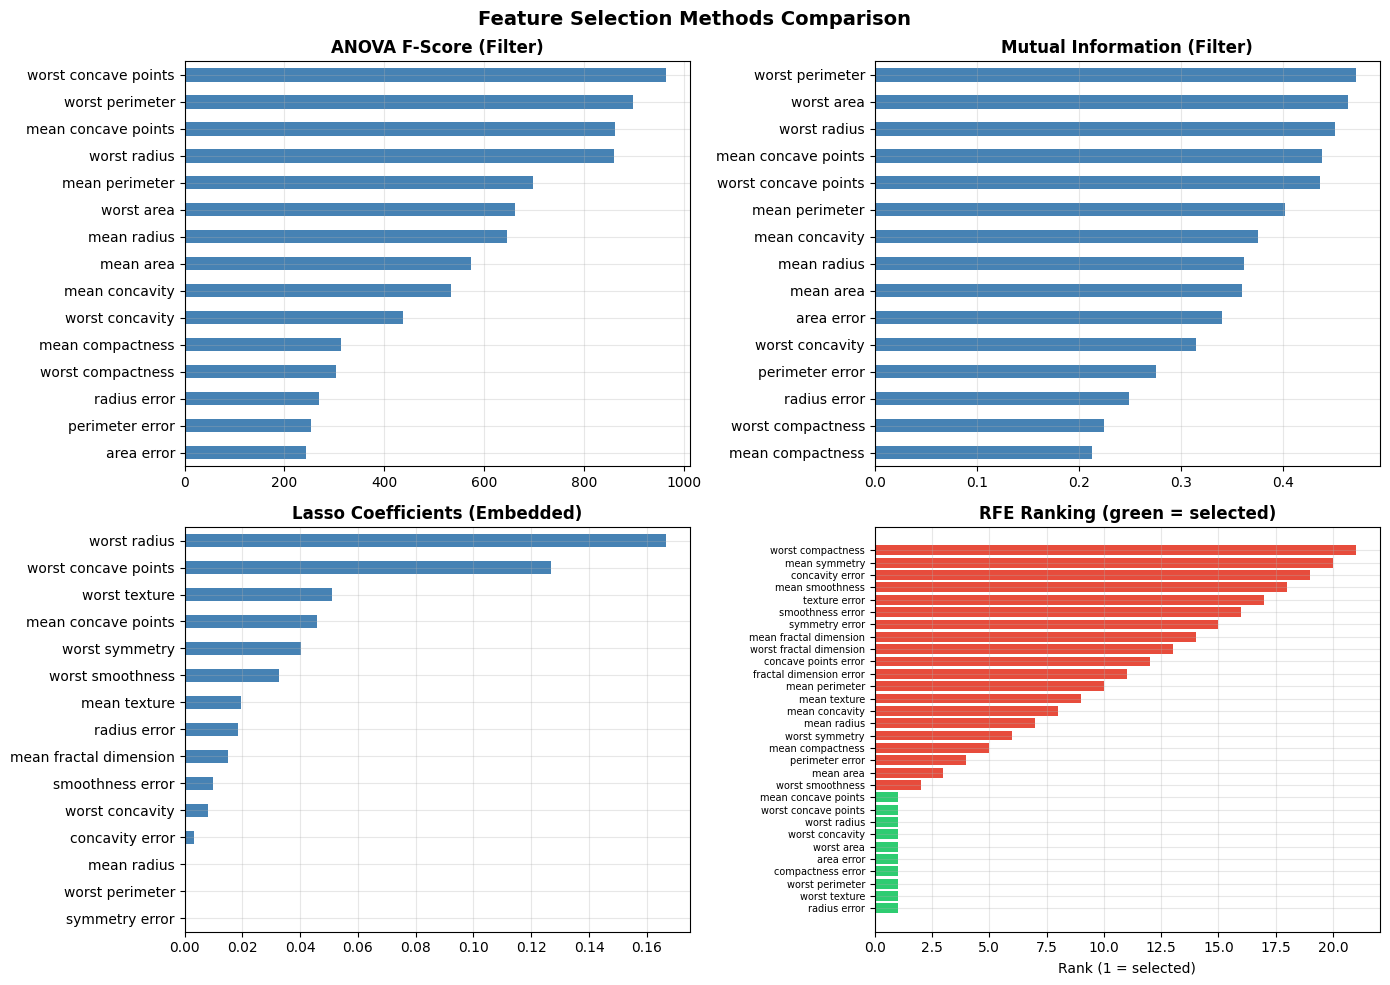


Top 5 features by F-score:           ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter']
Top 5 features by Mutual Info:       ['worst perimeter', 'worst area', 'worst radius', 'mean concave points', 'worst concave points']
RFE selected features:               ['mean concave points', 'radius error', 'area error', 'compactness error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']


In [27]:
# ── Feature Selection Demo ─────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import (SelectKBest, f_classif,
                                        mutual_info_classif, RFE)
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

data = load_breast_cancer()
X_bc, y_bc = data.data, data.target
feature_names = data.feature_names
print(f"Dataset: {X_bc.shape[0]} samples, {X_bc.shape[1]} features")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bc)

# ── Method 1: Filter — ANOVA F-test ──
selector_f = SelectKBest(f_classif, k=10)
selector_f.fit(X_bc, y_bc)
f_scores = pd.Series(selector_f.scores_, index=feature_names).sort_values(ascending=False)

# ── Method 2: Filter — Mutual Information ──
mi_scores = pd.Series(
    mutual_info_classif(X_bc, y_bc, random_state=42),
    index=feature_names
).sort_values(ascending=False)

# ── Method 3: Embedded — Lasso ──
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01, max_iter=5000, random_state=42)
lasso.fit(X_scaled, y_bc)
lasso_coefs = pd.Series(np.abs(lasso.coef_), index=feature_names).sort_values(ascending=False)

# ── Method 4: RFE with Logistic Regression ──
rfe = RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=10)
rfe.fit(X_scaled, y_bc)
rfe_selected = feature_names[rfe.support_]

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, scores) in zip(axes.flat, [
    ('ANOVA F-Score (Filter)', f_scores[:15]),
    ('Mutual Information (Filter)', mi_scores[:15]),
    ('Lasso Coefficients (Embedded)', lasso_coefs[:15]),
]):
    scores.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)

# RFE results
ax = axes[1, 1]
rfe_support = pd.Series(rfe.ranking_, index=feature_names).sort_values()
colors_rfe = ['#2ECC71' if r == 1 else '#E74C3C' for r in rfe_support.values]
ax.barh(range(len(rfe_support)), rfe_support.values, color=colors_rfe)
ax.set_yticks(range(len(rfe_support)))
ax.set_yticklabels(rfe_support.index, fontsize=7)
ax.set_title('RFE Ranking (green = selected)', fontweight='bold')
ax.set_xlabel('Rank (1 = selected)')
ax.grid(True, alpha=0.3)

plt.suptitle('Feature Selection Methods Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTop 5 features by F-score:           {list(f_scores.index[:5])}")
print(f"Top 5 features by Mutual Info:       {list(mi_scores.index[:5])}")
print(f"RFE selected features:               {list(rfe_selected)}")

---
## 5.2.2 Correlation Handling

### Definition
**Correlation** measures how strongly two variables move together.

**Multicollinearity** is when two or more features are highly correlated — they carry the same information, which can:
- Inflate model coefficients and make them unstable
- Make interpretation misleading
- Add noise without adding signal

### Math

**Pearson Correlation Coefficient:**
$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

Range: -1 to +1

| r value | Interpretation |
|---|---|
| 0.9 to 1.0 | Very strong positive |
| 0.5 to 0.9 | Moderate positive |
| -0.1 to 0.1 | Negligible |
| -0.9 to -1.0 | Very strong negative |

### Simple Example
```
Features: [height_cm, height_inches, weight_kg]

height_cm and height_inches are perfectly correlated (r=1.0)
→ Drop one! They carry IDENTICAL information.

height_cm and weight_kg: r ≈ 0.6 (moderate)
→ Keep both — they're related but different.
```

### Handling Strategy
```
If |r| > 0.85 between two features:
  Option 1: Drop one of them (keep the one more correlated with target)
  Option 2: Combine them (average, ratio, PCA)
  Option 3: Use a model robust to multicollinearity (trees, Ridge)
```

### Pearson Correlation — Step-by-Step Calculation

**Tiny dataset (5 houses):**

| House | Size (x) | Price (y) |
|---|---|---|
| A | 1000 | 200 |
| B | 1500 | 300 |
| C | 2000 | 400 |
| D | 2500 | 500 |
| E | 3000 | 600 |

**Step 1 — Compute means:**
$$\bar{x} = \frac{1000+1500+2000+2500+3000}{5} = 2000, \quad \bar{y} = \frac{200+300+400+500+600}{5} = 400$$

**Step 2 — Compute deviations and products:**

| House | $x_i - \bar{x}$ | $y_i - \bar{y}$ | product | $(x_i-\bar{x})^2$ | $(y_i-\bar{y})^2$ |
|---|---|---|---|---|---|
| A | -1000 | -200 | 200,000 | 1,000,000 | 40,000 |
| B | -500 | -100 | 50,000 | 250,000 | 10,000 |
| C | 0 | 0 | 0 | 0 | 0 |
| D | +500 | +100 | 50,000 | 250,000 | 10,000 |
| E | +1000 | +200 | 200,000 | 1,000,000 | 40,000 |
| **Sum** | | | **500,000** | **2,500,000** | **100,000** |

**Step 3 — Apply formula:**
$$r = \frac{500{,}000}{\sqrt{2{,}500{,}000 \times 100{,}000}} = \frac{500{,}000}{\sqrt{250{,}000{,}000{,}000}} = \frac{500{,}000}{500{,}000} = \mathbf{1.0}$$

→ Perfect positive correlation: as size increases, price increases proportionally.

---

**Now a weaker example — Size vs Age of house:**

| House | Size (x) | Age (z) |
|---|---|---|
| A | 1000 | 5 |
| B | 1500 | 20 |
| C | 2000 | 8 |
| D | 2500 | 35 |
| E | 3000 | 12 |

$\bar{x}=2000,\; \bar{z}=16$

Products: $(-1000)(-11) + (-500)(4) + (0)(-8) + (500)(19) + (1000)(-4)$
$= 11000 - 2000 + 0 + 9500 - 4000 = 14500$

$\sqrt{\sum(x-\bar{x})^2} = \sqrt{2{,}500{,}000} = 1581$, $\;\sqrt{\sum(z-\bar{z})^2} = \sqrt{714} \approx 26.7$... wait, let's compute:

$(z-\bar{z})^2$: $121 + 16 + 64 + 361 + 16 = 578$, so $\sqrt{578} \approx 24.0$

$$r = \frac{14500}{1581 \times 24.0} \approx \frac{14500}{37944} \approx \mathbf{0.38}$$

→ Weak positive correlation — older houses can be big or small, no strong pattern.

---

### VIF (Variance Inflation Factor)

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

Where $R^2_j$ = R² from regressing feature $j$ on **all other features**.

---

### What does VIF actually mean?

VIF answers one question:

> **"Can this feature be predicted using the other features?"**

- If **YES** (other features can predict it well) → it is **redundant** → high VIF → problem
- If **NO** (other features cannot predict it) → it is **independent** → low VIF → safe

---

### What is R² (needed to understand VIF)?

$R^2$ = how well a regression model fits the data.

- $R^2 = 1.0$ → perfect fit, 100% of variation explained
- $R^2 = 0.0$ → terrible fit, 0% explained
- $R^2 = 0.8$ → 80% of variation explained

**Simple example:**
```
Predict Height from Weight:
  Actual heights:    [160, 165, 170, 175, 180]
  Predicted heights: [161, 164, 171, 174, 181]  ← close!
  R² = 0.98  (weight explains 98% of height variation)
```

---

### VIF Step-by-Step — SIMPLE Example

**Dataset: 4 houses, 3 features**

| House | Size (sq ft) | Rooms | Age (years) |
|---|---|---|---|
| A | 1000 | 2 | 5  |
| B | 2000 | 4 | 8  |
| C | 3000 | 6 | 6  |
| D | 4000 | 8 | 7  |

Notice: **Size = 500 × Rooms exactly** → perfectly collinear!
But **Age** has no pattern with Size or Rooms.

---

#### Computing VIF for each feature:

**Step 1 — VIF for "Size"**

Regress Size using [Rooms, Age] as predictors.

Since Size = 500 × Rooms exactly, Rooms can perfectly predict Size.
$$R^2_{\text{Size}} = 1.0 \quad \text{(perfect prediction)}$$

$$\text{VIF}_{\text{Size}} = \frac{1}{1 - 1.0} = \frac{1}{0} = \infty$$

→ In practice this shows as a very large number (e.g. 10,000+)
→ **Size is perfectly redundant with Rooms. Drop it.**

---

**Step 2 — VIF for "Rooms"**

Regress Rooms using [Size, Age] as predictors.

Since Rooms = Size / 500 exactly, Size can perfectly predict Rooms.
$$R^2_{\text{Rooms}} = 1.0$$

$$\text{VIF}_{\text{Rooms}} = \frac{1}{1 - 1.0} = \infty$$

→ **Rooms is perfectly redundant with Size. Drop one of them.**

---

**Step 3 — VIF for "Age"**

Regress Age using [Size, Rooms] as predictors.

Age values [5, 8, 6, 7] have no linear pattern with Size or Rooms.
A regression of Age on Size+Rooms fits very poorly:
$$R^2_{\text{Age}} \approx 0.1 \quad \text{(almost no fit)}$$

$$\text{VIF}_{\text{Age}} = \frac{1}{1 - 0.1} = \frac{1}{0.9} \approx 1.11$$

→ VIF ≈ 1 → **Age is independent. Keep it.**

---

### Summary of this example

| Feature | $R^2$ (predicted by others) | VIF | Decision |
|---|---|---|---|
| Size | 1.0 | ∞ | ❌ Drop |
| Rooms | 1.0 | ∞ | ❌ Drop (keep one of Size/Rooms) |
| Age | 0.1 | 1.11 | ✅ Keep |

---

### VIF Scale Reference

| VIF | $R^2$ | Meaning | Action |
|---|---|---|---|
| 1.0 | 0.0 | Completely independent | ✅ Safe |
| 2.0 | 0.5 | 50% predictable by others | ✅ Usually fine |
| 5.0 | 0.8 | 80% predictable by others | ⚠️ Investigate |
| 10.0 | 0.9 | 90% predictable by others | ❌ Remove |
| 100.0 | 0.99 | 99% predictable by others | ❌ Definitely remove |
| ∞ | 1.0 | 100% predictable (perfect copy) | ❌ Exact duplicate |

**Key insight:** as $R^2$ approaches 1, VIF shoots toward infinity — that's why even a small change in $R^2$ near 1.0 causes a huge jump in VIF.

```
R²:   0.0   0.5   0.8   0.9   0.95  0.99  1.0
VIF:  1.0   2.0   5.0   10    20    100   ∞
            ↑              ↑
         fine           danger zone
```

---

### Quick comparison: Correlation vs VIF

| | Pearson r | VIF |
|---|---|---|
| Measures | Pairwise (2 features only) | One feature vs ALL others |
| Range | -1 to +1 | 1 to ∞ |
| Problem threshold | \|r\| > 0.85 | VIF > 5 or 10 |
| Catches 3-way collinearity | ✗ No | ✓ Yes |
| Easy to compute | ✓ Yes | Slightly more work |

> **Use both:** correlation matrix for quick pairwise check, VIF for rigorous diagnosis — especially when 3+ features are involved.

Found 29 highly correlated pairs (|r| > 0.85):
          Feature 1            Feature 2  Correlation
        mean radius       mean perimeter        0.998
       worst radius      worst perimeter        0.994
        mean radius            mean area        0.987
     mean perimeter            mean area        0.987
       worst radius           worst area        0.984
    worst perimeter           worst area        0.978
       radius error      perimeter error        0.973
        mean radius         worst radius        0.970
     mean perimeter      worst perimeter        0.970
     mean perimeter         worst radius        0.969
        mean radius      worst perimeter        0.965
          mean area         worst radius        0.963
          mean area      worst perimeter        0.959
          mean area           worst area        0.959
       radius error           area error        0.952
     mean perimeter           worst area        0.942
        mean radius           worst

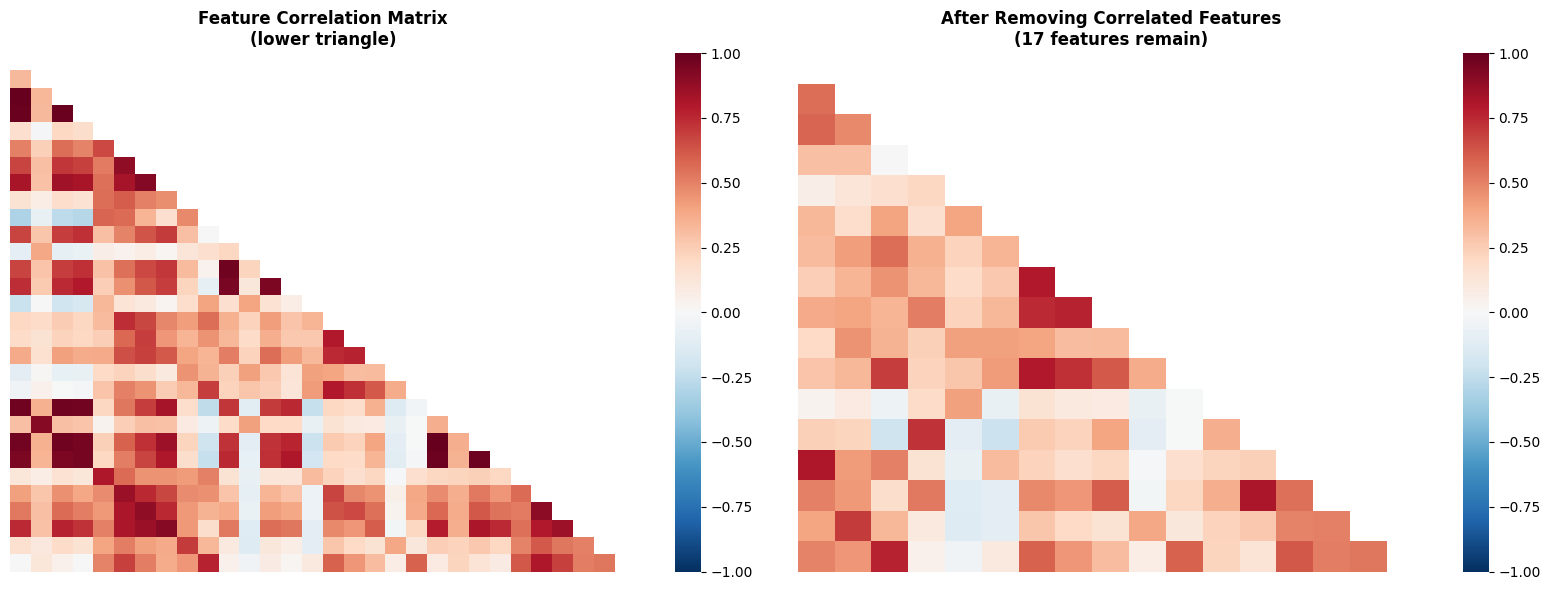

In [28]:
# ── Correlation Handling Demo ──────────────────────────────
import pandas as pd
import seaborn as sns

# Use breast cancer dataset
df_bc = pd.DataFrame(X_bc, columns=feature_names)

corr_matrix = df_bc.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0],
            xticklabels=False, yticklabels=False)
axes[0].set_title('Feature Correlation Matrix\n(lower triangle)', fontweight='bold')

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(r, 3)
            })

df_corr = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
print(f"Found {len(df_corr)} highly correlated pairs (|r| > 0.85):")
print(df_corr.to_string(index=False))

# Show which to drop
to_drop = set()
for _, row in df_corr.iterrows():
    # Drop the one with lower correlation to target
    c1 = abs(np.corrcoef(df_bc[row['Feature 1']], y_bc)[0, 1])
    c2 = abs(np.corrcoef(df_bc[row['Feature 2']], y_bc)[0, 1])
    if c1 < c2:
        to_drop.add(row['Feature 1'])
    else:
        to_drop.add(row['Feature 2'])

print(f"\nRecommended to drop ({len(to_drop)} features): {to_drop}")
print(f"Remaining features: {X_bc.shape[1] - len(to_drop)}")

# Reduced heatmap
keep_cols = [c for c in df_bc.columns if c not in to_drop]
corr_reduced = df_bc[keep_cols].corr()
mask2 = np.triu(np.ones_like(corr_reduced, dtype=bool))
sns.heatmap(corr_reduced, mask=mask2, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[1],
            xticklabels=False, yticklabels=False)
axes[1].set_title(f'After Removing Correlated Features\n({len(keep_cols)} features remain)',
                   fontweight='bold')

plt.tight_layout()
plt.show()

---
## 5.2.3 PCA (Principal Component Analysis)

### Definition
PCA is a **dimensionality reduction** technique that transforms many correlated features into a smaller set of uncorrelated **principal components** (PCs) that capture the maximum variance in the data.

### Simple Analogy
> Imagine photographing a 3D object. A photo is a 2D projection — you lose depth but keep the most useful view. PCA finds the **best angle** to project your high-dimensional data so you preserve the most information.

### How It Works — Step by Step
```
Step 1: Standardize features (mean=0, std=1)

Step 2: Compute Covariance Matrix
        Measures how features vary together

Step 3: Find Eigenvectors (principal components)
        Directions in feature space with maximum variance

Step 4: Sort by Eigenvalue (how much variance each PC explains)
        PC1 explains most variance, PC2 second most, etc.

Step 5: Keep top K components
        Project data onto K principal components
```

### Math (simplified)

**Covariance Matrix:**
$$C = \frac{1}{n-1} X^T X$$

**Eigendecomposition:**
$$C \mathbf{v} = \lambda \mathbf{v}$$

Where:
- $\mathbf{v}$ = eigenvector (direction of principal component)
- $\lambda$ = eigenvalue (amount of variance explained)

**Explained Variance Ratio:**
$$\text{EVR}_k = \frac{\lambda_k}{\sum_j \lambda_j}$$

**Simple example:**
```
Original: 30 features
PC1 explains 45% of variance
PC2 explains 20%
PC3 explains 10%
...
Cumulative:
  3 PCs = 75% variance   ← good trade-off
  5 PCs = 85% variance
 10 PCs = 95% variance
```

### Diagram
```
Original 2D data:          After PCA:
                            Rotated to new axes
  y |   .  .                
    |  . . .    PC1 →        
    | . . . .   (most variance)
    |  . . .   
    +-------x   PC2 ↑ (less variance, perpendicular to PC1)
```

### When to Use / Not Use
| Use PCA | Avoid PCA |
|---|---|
| High dimensionality (>50 features) | When interpretability of features is critical |
| Features are correlated | When data is very small |
| Visualization (2D/3D) | Categorical features (use MCA instead) |
| Preprocessing before clustering | When you need to explain feature importance |

Original features: 30
Components for 90% variance: 7
Components for 95% variance: 10

Variance per component (top 10):
  PC 1: 0.443 (44.3%) ████████████████████████████████████████████
  PC 2: 0.190 (19.0%) ██████████████████
  PC 3: 0.094 (9.4%) █████████
  PC 4: 0.066 (6.6%) ██████
  PC 5: 0.055 (5.5%) █████
  PC 6: 0.040 (4.0%) ████
  PC 7: 0.023 (2.3%) ██
  PC 8: 0.016 (1.6%) █
  PC 9: 0.014 (1.4%) █
  PC10: 0.012 (1.2%) █


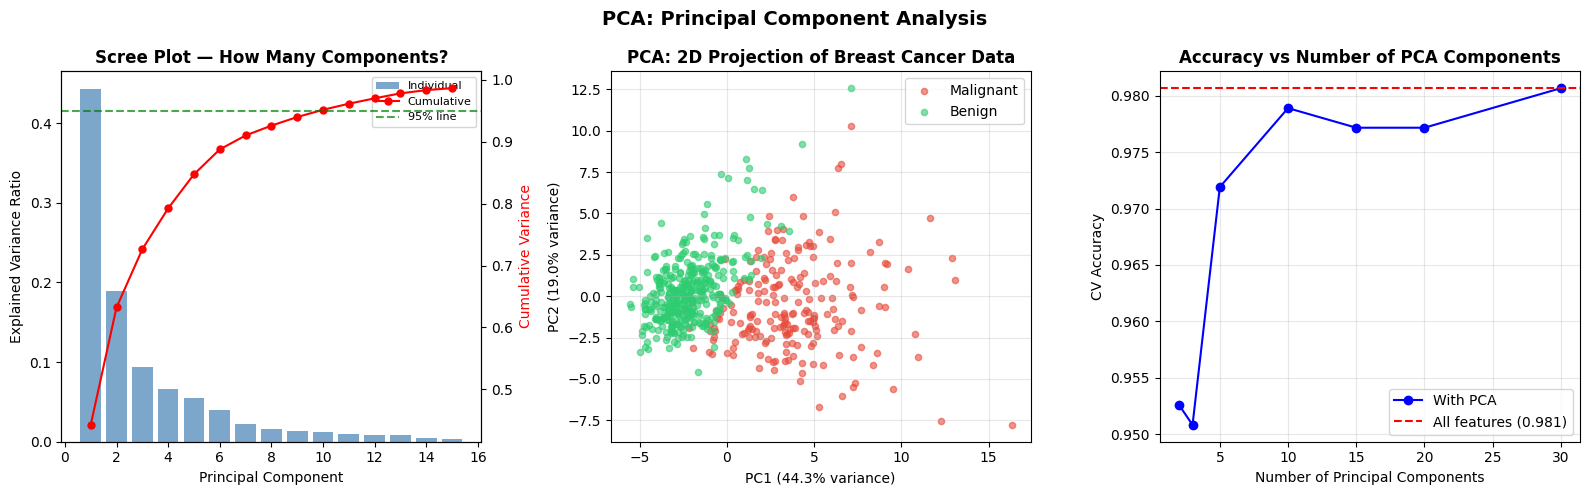

In [29]:
# ── PCA Demo ────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_std = scaler.fit_transform(X_bc)

# Full PCA to analyze variance
pca_full = PCA(random_state=42)
pca_full.fit(X_std)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
n_95 = np.searchsorted(cum_evr, 0.95) + 1
n_90 = np.searchsorted(cum_evr, 0.90) + 1

print(f"Original features: {X_std.shape[1]}")
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"\nVariance per component (top 10):")
for i, v in enumerate(evr[:10]):
    bar = '█' * int(v * 100)
    print(f"  PC{i+1:2d}: {v:.3f} ({v*100:.1f}%) {bar}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scree plot
ax = axes[0]
ax.bar(range(1, 16), evr[:15], color='steelblue', alpha=0.7, label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, 16), cum_evr[:15], 'r-o', ms=5, label='Cumulative')
ax2.axhline(0.95, color='green', linestyle='--', alpha=0.7, label='95% line')
ax2.set_ylabel('Cumulative Variance', color='red')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot — How Many Components?', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8)

# 2D projection (PC1 vs PC2)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_std)
ax = axes[1]
for cls, name, color in [(0, 'Malignant', '#E74C3C'), (1, 'Benign', '#2ECC71')]:
    mask = y_bc == cls
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=color, label=name, alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
ax.set_title('PCA: 2D Projection of Breast Cancer Data', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# Compare model performance with/without PCA
from sklearn.model_selection import cross_val_score
n_components_list = [2, 3, 5, 10, 15, 20, 30]
cv_scores = []
for n in n_components_list:
    pca_n = PCA(n_components=n, random_state=42)
    X_pca_n = pca_n.fit_transform(X_std)
    scores = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=42),
        X_pca_n, y_bc, cv=5, scoring='accuracy'
    )
    cv_scores.append(scores.mean())

# Baseline (all features)
baseline = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_std, y_bc, cv=5, scoring='accuracy'
).mean()

ax = axes[2]
ax.plot(n_components_list, cv_scores, 'b-o', ms=6, label='With PCA')
ax.axhline(baseline, color='red', linestyle='--', label=f'All features ({baseline:.3f})')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('CV Accuracy')
ax.set_title('Accuracy vs Number of PCA Components', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('PCA: Principal Component Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5.2.4 Domain-Based Features

### Definition
Domain-based features are features created using **expert knowledge** about the problem domain — transformations or combinations that a human expert would recognize as meaningful.

### Why It's Powerful
> Statistical methods find patterns in numbers. Domain knowledge tells you **which patterns are meaningful**. A model doesn't know that hour=2am + high_amount = suspicious fraud pattern — you have to tell it.

### Examples by Domain

| Domain | Raw Feature | Engineered Feature | Why |
|---|---|---|---|
| Finance | transaction_time | `is_late_night` (2am-5am) | Fraud peaks late night |
| Finance | amount, avg_amount | `amount_vs_avg_ratio` | Unusually large txn = suspicious |
| E-commerce | clicks, purchases | `conversion_rate` | Product appeal metric |
| Healthcare | diastolic, systolic | `pulse_pressure` = sys - dia | Clinical risk marker |
| NLP | sentence | `sentence_length`, `!_count` | Urgency/emotion signal |
| Time series | timestamp | `hour`, `day_of_week`, `is_holiday` | Seasonality patterns |

### Common Patterns
```
1. Ratios:           price_per_sqft = price / sqft
2. Differences:      age_at_purchase = purchase_date - birth_date
3. Aggregations:     user_avg_spend (over last 30 days)
4. Binning:          age → [child, teen, adult, senior]
5. Interaction terms: feature_A × feature_B
6. Lag features:     sales_yesterday, sales_last_week
7. Flags/Indicators: is_first_purchase, is_weekend
```

### When to Use
- Always — domain features often give the biggest model improvements
- Especially when raw features alone give mediocre performance
- When working with time, geographic, financial, or medical data

Fraud rate: 11.67%

 F1 Score Comparison
 Raw features only:         0.320
 With domain features:      0.380
 Improvement:               +0.060


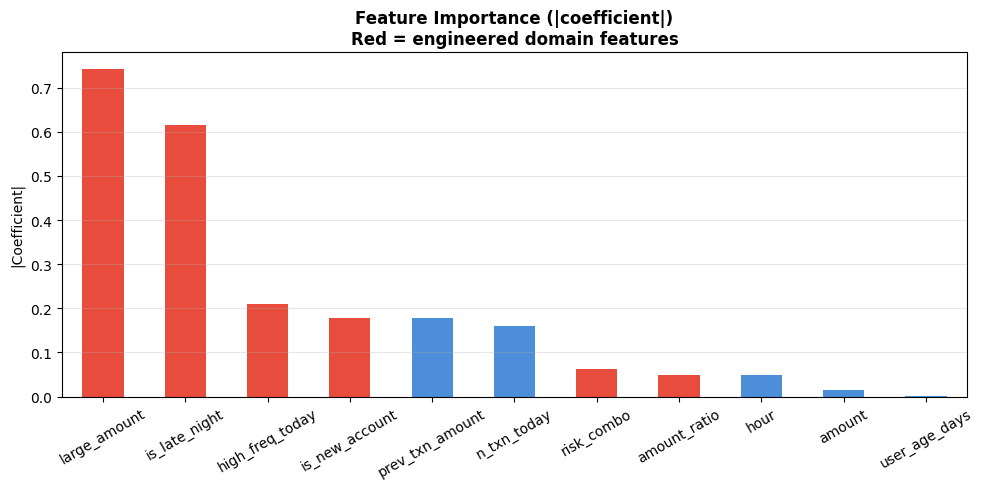

In [30]:
# ── Domain-Based Feature Engineering Demo ──────────────────
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

# Simulate a fraud detection dataset
np.random.seed(42)
n = 3000

df = pd.DataFrame({
    'amount':         np.random.exponential(100, n),
    'hour':           np.random.randint(0, 24, n),
    'merchant_cat':   np.random.choice(['retail', 'food', 'travel', 'online'], n),
    'user_age_days':  np.random.randint(1, 2000, n),
    'prev_txn_amount':np.random.exponential(80, n),
    'n_txn_today':    np.random.poisson(3, n),
})

# Fraud pattern: large amount + late night + new account
fraud_score = (
    (df['amount'] > 200).astype(float) * 2 +
    ((df['hour'] < 5) | (df['hour'] > 22)).astype(float) * 1.5 +
    (df['user_age_days'] < 30).astype(float) * 1.5 +
    (df['n_txn_today'] > 8).astype(float) * 1.0
)
prob_fraud = 1 / (1 + np.exp(-fraud_score + 3))
df['is_fraud'] = (np.random.random(n) < prob_fraud).astype(int)

print(f"Fraud rate: {df['is_fraud'].mean():.2%}")

# ── Raw features only ──
X_raw = df[['amount', 'hour', 'user_age_days', 'prev_txn_amount', 'n_txn_today']].values
y_fraud = df['is_fraud'].values

scaler = StandardScaler()
X_raw_s = scaler.fit_transform(X_raw)
score_raw = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_raw_s, y_fraud, cv=5, scoring='f1'
).mean()

# ── Add domain features ──
df['is_late_night']    = ((df['hour'] < 5) | (df['hour'] > 22)).astype(int)
df['is_new_account']   = (df['user_age_days'] < 30).astype(int)
df['amount_ratio']     = df['amount'] / (df['prev_txn_amount'] + 1)
df['high_freq_today']  = (df['n_txn_today'] > 5).astype(int)
df['large_amount']     = (df['amount'] > 200).astype(int)
df['risk_combo']       = df['is_late_night'] * df['large_amount']  # interaction!

domain_cols = ['amount', 'hour', 'user_age_days', 'prev_txn_amount', 'n_txn_today',
               'is_late_night', 'is_new_account', 'amount_ratio',
               'high_freq_today', 'large_amount', 'risk_combo']
X_domain = df[domain_cols].values
X_domain_s = StandardScaler().fit_transform(X_domain)

score_domain = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_domain_s, y_fraud, cv=5, scoring='f1'
).mean()

print(f"\n{'='*40}")
print(f" F1 Score Comparison")
print('='*40)
print(f" Raw features only:         {score_raw:.3f}")
print(f" With domain features:      {score_domain:.3f}")
print(f" Improvement:               +{(score_domain-score_raw):.3f}")

# Visualize feature importance
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_domain_s, y_fraud)

coef_df = pd.Series(np.abs(model.coef_[0]), index=domain_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E74C3C' if c in ['is_late_night','is_new_account','amount_ratio',
                              'high_freq_today','large_amount','risk_combo']
          else '#4C8EDA' for c in coef_df.index]
coef_df.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Feature Importance (|coefficient|)\nRed = engineered domain features',
              fontweight='bold')
ax.set_ylabel('|Coefficient|')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
# 5.4 Explainability

## What is Model Explainability?

**Definition:** The ability to understand **why** a model made a specific prediction — which features drove the decision, how much each feature contributed, and whether the model's reasoning is trustworthy.

### Why It Matters
```
"Your loan was denied."   ←  Black box — unfair, legally risky

"Your loan was denied because:
  - Credit score (700) was below threshold (+30% influence)
  - High debt-to-income ratio   (+25% influence)
  - Short credit history        (+20% influence)"  ← Explainable
```

**Legal/Business requirements:** GDPR (EU), FCRA (US credit), medical AI, hiring algorithms — all require explanation.

### Explainability Spectrum
```
Most Interpretable              Least Interpretable
        ←──────────────────────────────────→
Linear  Decision  Random   XGBoost   Neural   Deep
Regress  Tree     Forest             Network  Learning
  ↑                                             ↑
Easy to understand                 Need SHAP/LIME
```

---
## 5.4.1 SHAP (SHapley Additive exPlanations)

### Definition
SHAP assigns each feature a **contribution score** (Shapley value) for a specific prediction, based on game theory. It answers: *"How much did feature X contribute to this prediction vs the baseline?"*

### Origin: Game Theory
> Three players (A, B, C) collaborate and earn $300. How do we fairly divide the reward?
> Shapley value = average marginal contribution when joining different coalitions.

In ML: players = features, reward = prediction value.

### Math
$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

**Simplified intuition:**
- For every possible combination of features
- Measure how much adding feature $i$ changes the prediction
- Average over all combinations → that's the Shapley value

**Simple 2-feature example:**
```
Model predicts salary. Baseline = $50k average.
Actual prediction for Alice: $75k

SHAP breakdown:
  Base value:        $50k
  + experience=10yr: +$18k  (SHAP value)
  + city=NYC:        + $7k  (SHAP value)
  = Prediction:      $75k  ✓
```

### Key Property (Additivity)
$$f(x) = \text{base\_value} + \sum_{i=1}^{n} \phi_i$$

SHAP values always **sum exactly** to the difference between the prediction and baseline.

### SHAP Plot Types
```
1. Waterfall Plot — single prediction breakdown
   [base] → [+feature A] → [-feature B] → [prediction]

2. Beeswarm/Summary Plot — all samples, all features
   Shows distribution of SHAP values across dataset

3. Bar Plot — mean |SHAP| per feature = global importance

4. Dependence Plot — SHAP value vs feature value
   Shows how one feature's effect changes with its value
```

### When to Use
- Any model (model-agnostic), but works best with tree models (TreeSHAP is fast)
- When you need to explain individual predictions to stakeholders
- When debugging why a model makes surprising predictions
- For compliance/regulatory requirements

In [31]:
import sys
!{sys.executable} -m pip install "shap==0.46.0" "numpy>=1.21,<2"


DEPRECATION: fds-ce-carbon-api 5.3.3 has a non-standard dependency specifier aenum>=2.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of fds-ce-carbon-api or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: fds-ce-carbon-api 5.3.3 has a non-standard dependency specifier certifi>=2020.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of fds-ce-carbon-api or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: fds-ce-carbon-api 5.3.3 has a non-standard dependency specifier chardet>=3.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of fds-ce-carbon-api or contact the autho

Model Accuracy: 0.956

SHAP values shape: (114, 30)
(One SHAP value per sample per feature)


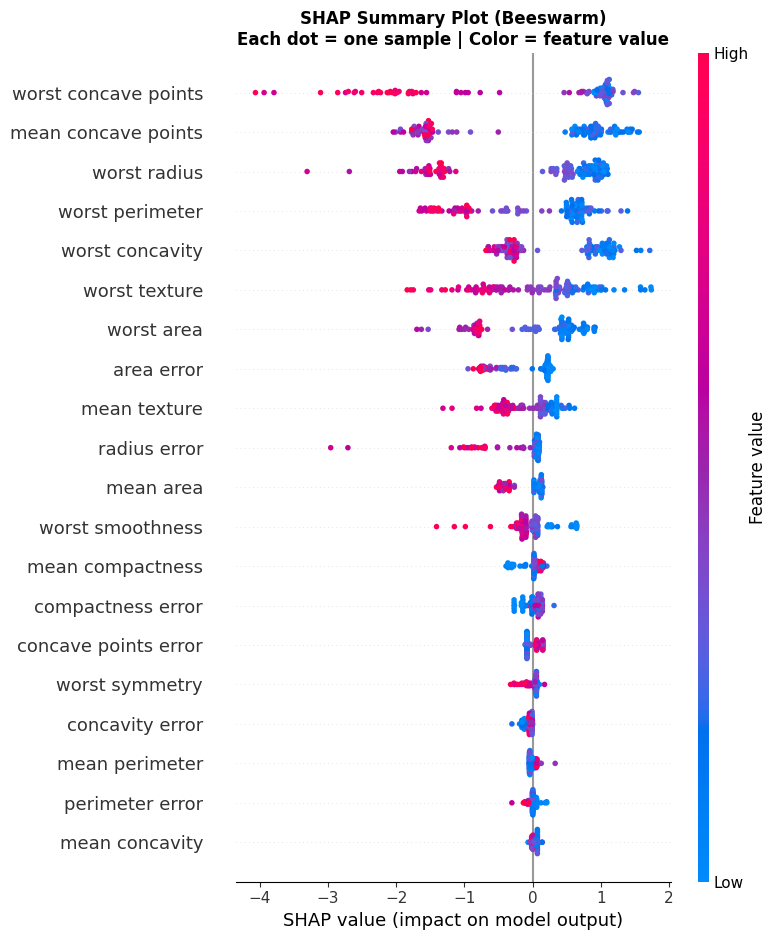

→ Right of center = pushes toward class 1 (benign)
→ Left of center  = pushes toward class 0 (malignant)


In [32]:
# ── SHAP Demo ────────────────────────────────────────────────
# Install if needed: pip install shap
import shap
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Use breast cancer dataset for clear feature names
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target
feat_names = list(data.feature_names)

Xtr, Xte, ytr, yte = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

# Train a GBM model
gbm = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gbm.fit(Xtr, ytr)
print(f"Model Accuracy: {gbm.score(Xte, yte):.3f}")

# Compute SHAP values using TreeExplainer (fast for tree models)
explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(Xte)

print(f"\nSHAP values shape: {shap_values.shape}")
print(f"(One SHAP value per sample per feature)")

# ── Plot 1: Beeswarm summary plot ──
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, Xte, feature_names=feat_names,
                  show=False, plot_type='dot')
plt.title('SHAP Summary Plot (Beeswarm)\nEach dot = one sample | Color = feature value',
           fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()
print("→ Right of center = pushes toward class 1 (benign)")
print("→ Left of center  = pushes toward class 0 (malignant)")

Sample 5: True label = malignant
Prediction: malignant (prob=0.000)


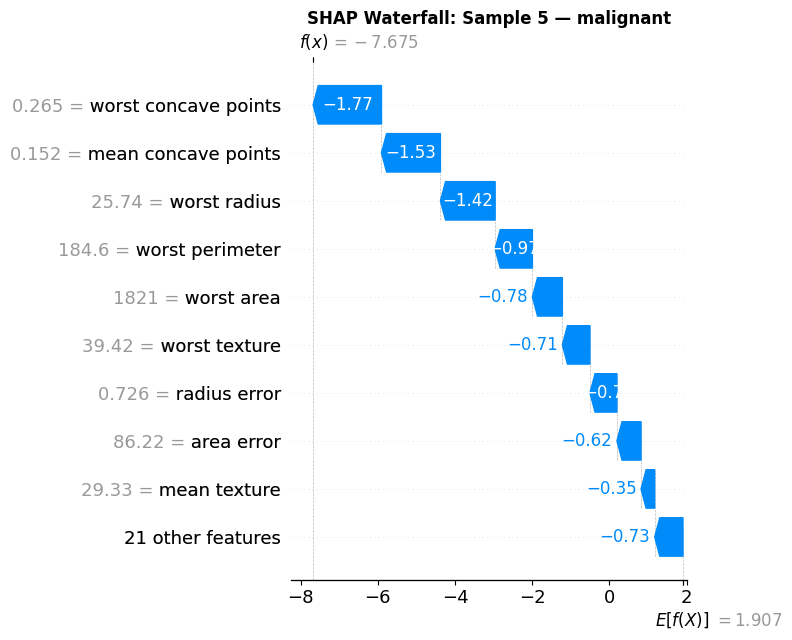

→ Each bar shows how much a feature pushed the prediction up (red) or down (blue)


In [33]:
# ── SHAP: Waterfall plot for a single prediction ──────────
import shap

# Pick one sample to explain
sample_idx = 5
sample_pred = gbm.predict(Xte[sample_idx:sample_idx+1])[0]
sample_prob = gbm.predict_proba(Xte[sample_idx:sample_idx+1])[0, 1]
true_label = yte[sample_idx]

print(f"Sample {sample_idx}: True label = {data.target_names[true_label]}")
print(f"Prediction: {data.target_names[sample_pred]} (prob={sample_prob:.3f})")

# Waterfall using Explanation object
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=Xte[sample_idx],
    feature_names=feat_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.title(f'SHAP Waterfall: Sample {sample_idx} — {data.target_names[true_label]}',
           fontweight='bold')
plt.tight_layout()
plt.show()
print("→ Each bar shows how much a feature pushed the prediction up (red) or down (blue)")

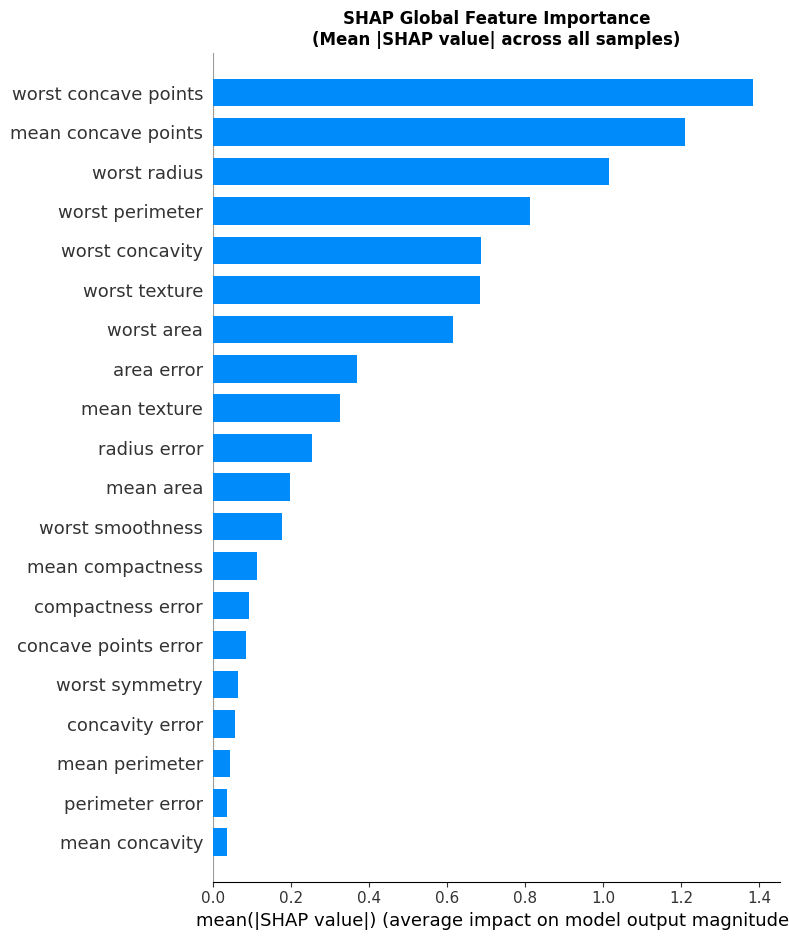

Top 5 by SHAP:    ['worst concave points', 'mean concave points', 'worst radius', 'worst perimeter', 'worst concavity']
Top 5 by sklearn: ['mean concave points', 'worst concave points', 'worst radius', 'worst perimeter', 'worst texture']


In [34]:
# ── SHAP: Bar plot (global feature importance) ─────────────

import pandas as pd
import numpy as np
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, Xte, feature_names=feat_names,
                  plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance\n(Mean |SHAP value| across all samples)',
           fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Compare SHAP importance vs sklearn importance
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feat_names
).sort_values(ascending=False)

sklearn_importance = pd.Series(
    gbm.feature_importances_,
    index=feat_names
).sort_values(ascending=False)

print("Top 5 by SHAP:   ", list(shap_importance.index[:5]))
print("Top 5 by sklearn:", list(sklearn_importance.index[:5]))

---
## 5.4.2 Feature Importance

### Definition
Feature importance measures **how much each feature contributed to the model's predictive performance**. Different models calculate this differently.

### Types of Feature Importance

#### 1. Tree-based Impurity Importance (Gini / MSE reduction)
$$\text{Importance}(f) = \sum_{\text{nodes where } f \text{ is used}} \frac{N_t}{N} \cdot \Delta\text{impurity}$$

- Available in: Decision Trees, Random Forest, GBM
- Fast but can be biased toward high-cardinality features

#### 2. Permutation Importance
```
1. Evaluate model: baseline accuracy = 0.92
2. Shuffle feature X (break its signal)
3. Re-evaluate: accuracy = 0.85
4. Importance(X) = 0.92 - 0.85 = 0.07

A feature that doesn't matter → shuffling doesn't change accuracy
An important feature → shuffling hurts accuracy a lot
```

- Model-agnostic (works with any model)
- More reliable than impurity-based
- Slow for large datasets

#### 3. Coefficient Importance (Linear Models)
$$\text{Importance}(f_i) = |\beta_i| \quad \text{(after standardizing features)}$$

### Diagram: What Importance Tells You
```
High Importance Feature:           Low Importance Feature:
The model splits on it often        The model ignores it
and gets big accuracy gains         (it's noise or redundant)

Tip: Low importance ≠ bad feature   ← it might be important
     but correlated with another    ← split between correlated
     high-importance feature        ← features equally
```

### When to Use
- Quick model debugging: "Is the model using the right features?"
- Feature selection: drop near-zero importance features
- Business justification: explain model to non-technical stakeholders
- Catching data leakage: unusually high importance may indicate leakage

---
## 5.4.3 Model Interpretability

### Definition
Model interpretability is the degree to which a human can **understand and trust** a model's decision-making process.

Two dimensions:
- **Global interpretability:** Understanding overall behavior (which features matter most?)
- **Local interpretability:** Understanding one specific prediction (why was THIS person denied?)

### Interpretability Techniques

| Technique | Type | Works With | What It Shows |
|---|---|---|---|
| Decision Tree visualization | Global | Decision trees | Exact decision rules |
| Feature importance | Global | Tree models, linear | Aggregate feature effects |
| SHAP summary plot | Global | Any | Distribution of feature effects |
| SHAP waterfall | Local | Any | One prediction explained |
| LIME | Local | Any | Local linear approximation |
| Partial Dependence Plot (PDP) | Global | Any | Effect of one feature on average |
| ICE plot | Local | Any | Effect of one feature per sample |

### Partial Dependence Plot (PDP)

**Definition:** Shows the **average marginal effect** of one (or two) features on the prediction, after marginalizing over all other features.

$$\text{PDP}(x_s) = \mathbb{E}_{X_c}[f(x_s, X_c)]$$

**Simple example:**
> How does `age` affect predicted salary on average?
> Fix age=25 → average all predictions → one point
> Fix age=30 → average all predictions → another point
> Connect dots → PDP curve

### ICE Plots (Individual Conditional Expectation)
Same as PDP but shows each sample's curve instead of the average — reveals heterogeneous effects.

```
PDP:  ─────────────────── (average trend)
      Hides individual variation

ICE:  ╱╲╱╲──────────────  (some go up)
      ─────╲╱─────────── (some go down)
      ───────────────╱╲─  (some stay flat)
      Shows individual variation — more insight!
```

In [37]:
# ── Model Interpretability Demo ────────────────────────────
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import DecisionTreeClassifier, export_text

# ── Part 1: Simple Decision Tree — fully interpretable ──
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(Xtr, ytr)
print(f"Decision Tree (depth=3) Accuracy: {dt.score(Xte, yte):.3f}")
print(f"GBM (depth=3) Accuracy:           {gbm.score(Xte, yte):.3f}")
print(f"\nDecision rules (first 3 levels):")
tree_rules = export_text(dt, feature_names=feat_names, max_depth=3)
print(tree_rules[:1500])  # first part of rules

Decision Tree (depth=3) Accuracy: 0.947
GBM (depth=3) Accuracy:           0.956

Decision rules (first 3 levels):
|--- mean concave points <= 0.05
|   |--- worst radius <= 16.83
|   |   |--- area error <= 48.70
|   |   |   |--- class: 1
|   |   |--- area error >  48.70
|   |   |   |--- class: 0
|   |--- worst radius >  16.83
|   |   |--- mean texture <= 16.19
|   |   |   |--- class: 1
|   |   |--- mean texture >  16.19
|   |   |   |--- class: 0
|--- mean concave points >  0.05
|   |--- worst concave points <= 0.15
|   |   |--- worst perimeter <= 115.25
|   |   |   |--- class: 1
|   |   |--- worst perimeter >  115.25
|   |   |   |--- class: 0
|   |--- worst concave points >  0.15
|   |   |--- fractal dimension error <= 0.01
|   |   |   |--- class: 0
|   |   |--- fractal dimension error >  0.01
|   |   |   |--- class: 1



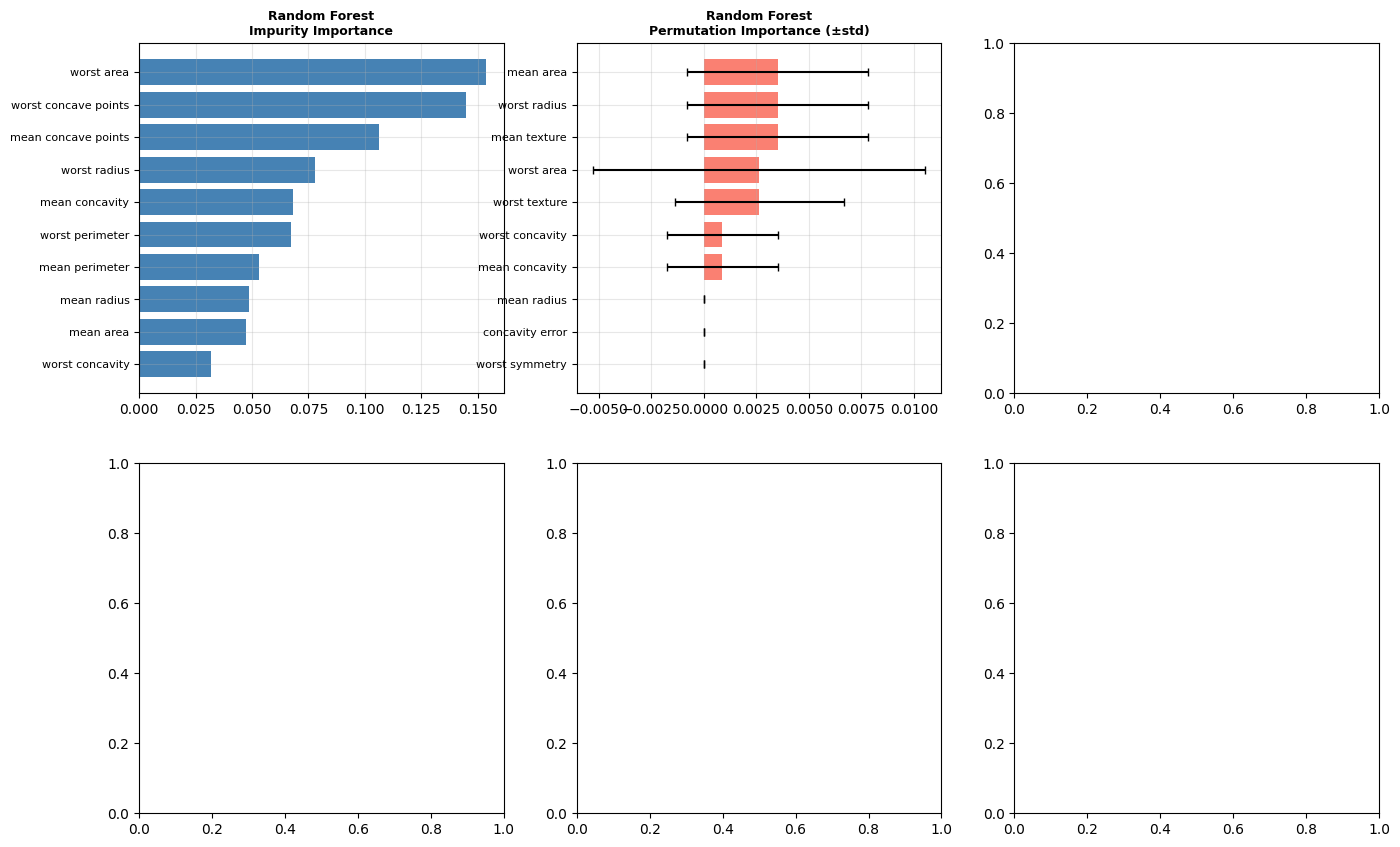

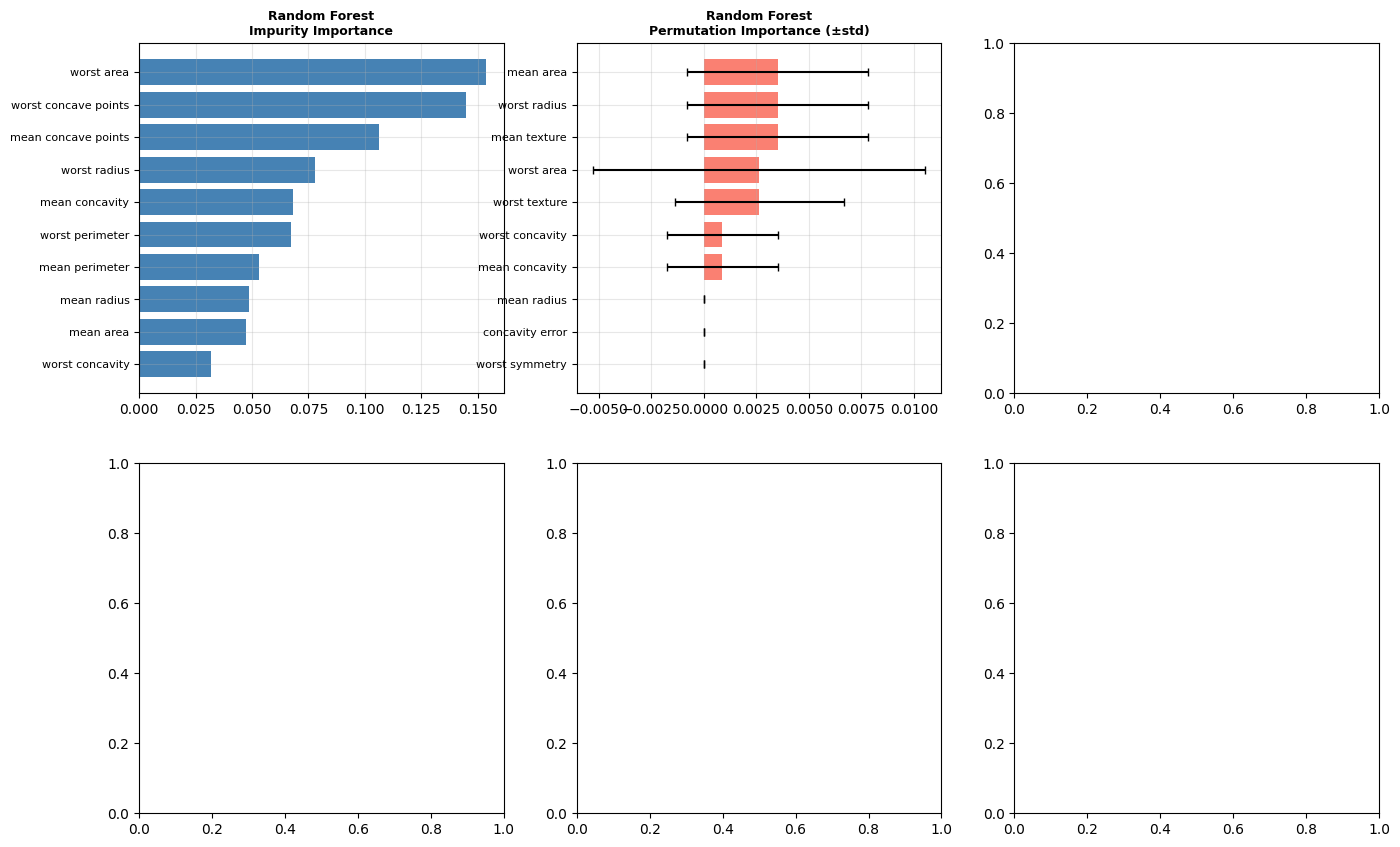

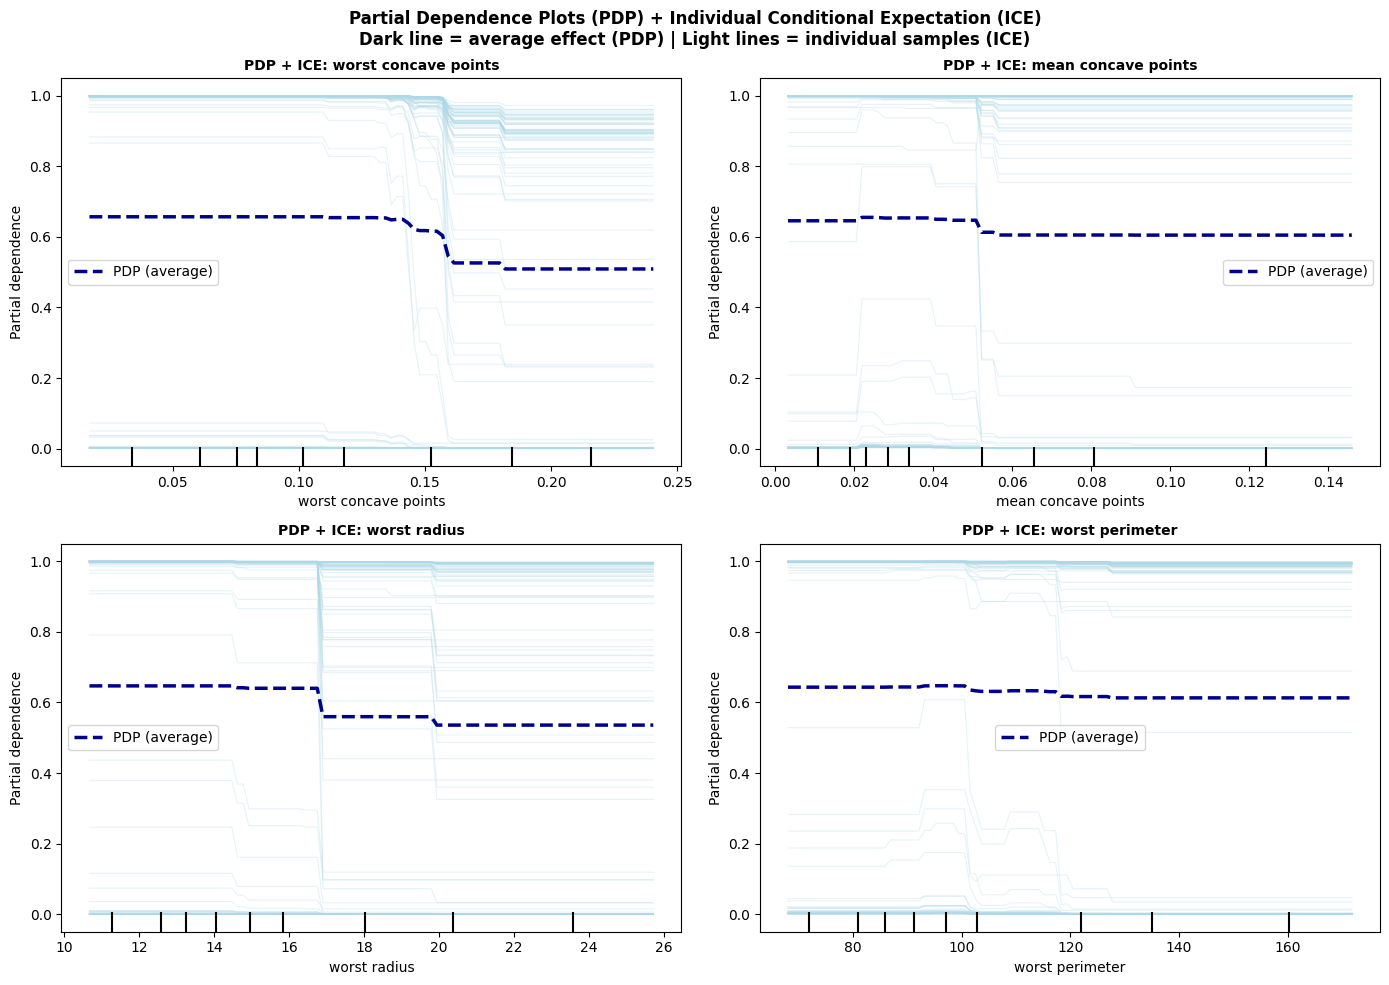

In [38]:
# ── Part 2: Partial Dependence Plots ───────────────────────
from sklearn.inspection import PartialDependenceDisplay
import warnings; warnings.filterwarnings('ignore')

# Get top 4 features by SHAP importance
top_features = shap_importance.index[:4].tolist()
top_idx = [feat_names.index(f) for f in top_features]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (feat_name, feat_idx) in zip(axes.flat, zip(top_features, top_idx)):
    # PDP + ICE together
    disp = PartialDependenceDisplay.from_estimator(
        gbm, Xte, [feat_idx],
        feature_names=feat_names,
        kind='both',          # 'average' = PDP, 'individual' = ICE, 'both' = both
        subsample=100,
        ice_lines_kw={'color': 'lightblue', 'alpha': 0.3, 'linewidth': 0.8},
        pd_line_kw={'color': 'darkblue', 'linewidth': 2.5, 'label': 'PDP (average)'},
        ax=ax,
        random_state=42
    )
    ax.set_title(f'PDP + ICE: {feat_name}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Predicted Probability (Benign)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Partial Dependence Plots (PDP) + Individual Conditional Expectation (ICE)\n'
             'Dark line = average effect (PDP) | Light lines = individual samples (ICE)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

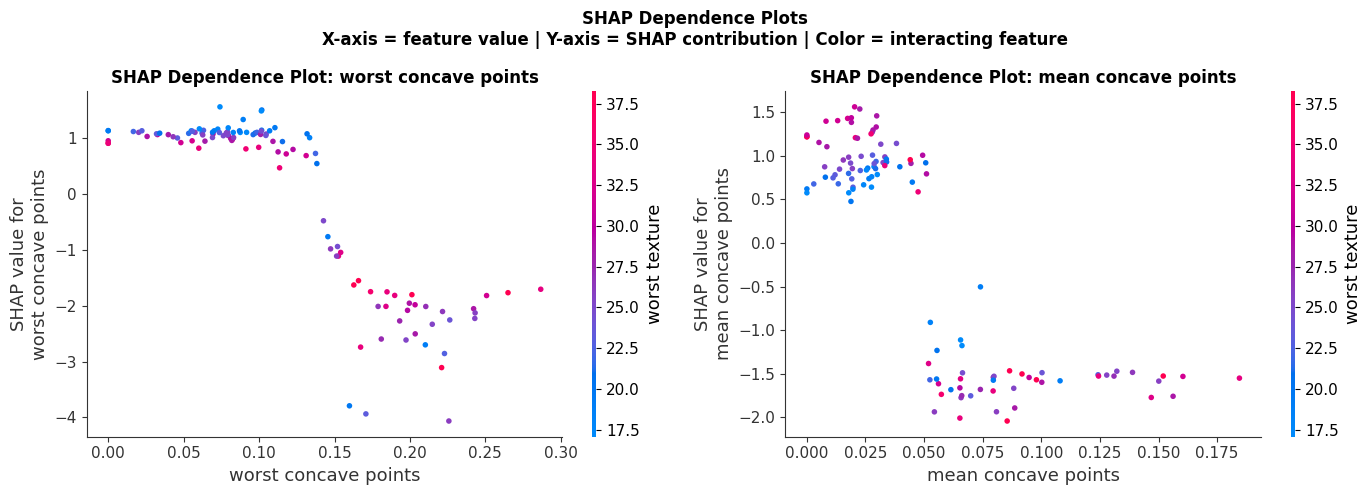

In [39]:
# ── Part 3: SHAP Dependence Plot ───────────────────────────
# Shows interaction between one feature's value and its SHAP value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_2 = shap_importance.index[:2].tolist()

for ax, feat in zip(axes, top_2):
    shap.dependence_plot(
        feat, shap_values, Xte,
        feature_names=feat_names,
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP Dependence Plot: {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots\n'
             'X-axis = feature value | Y-axis = SHAP contribution | Color = interacting feature',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

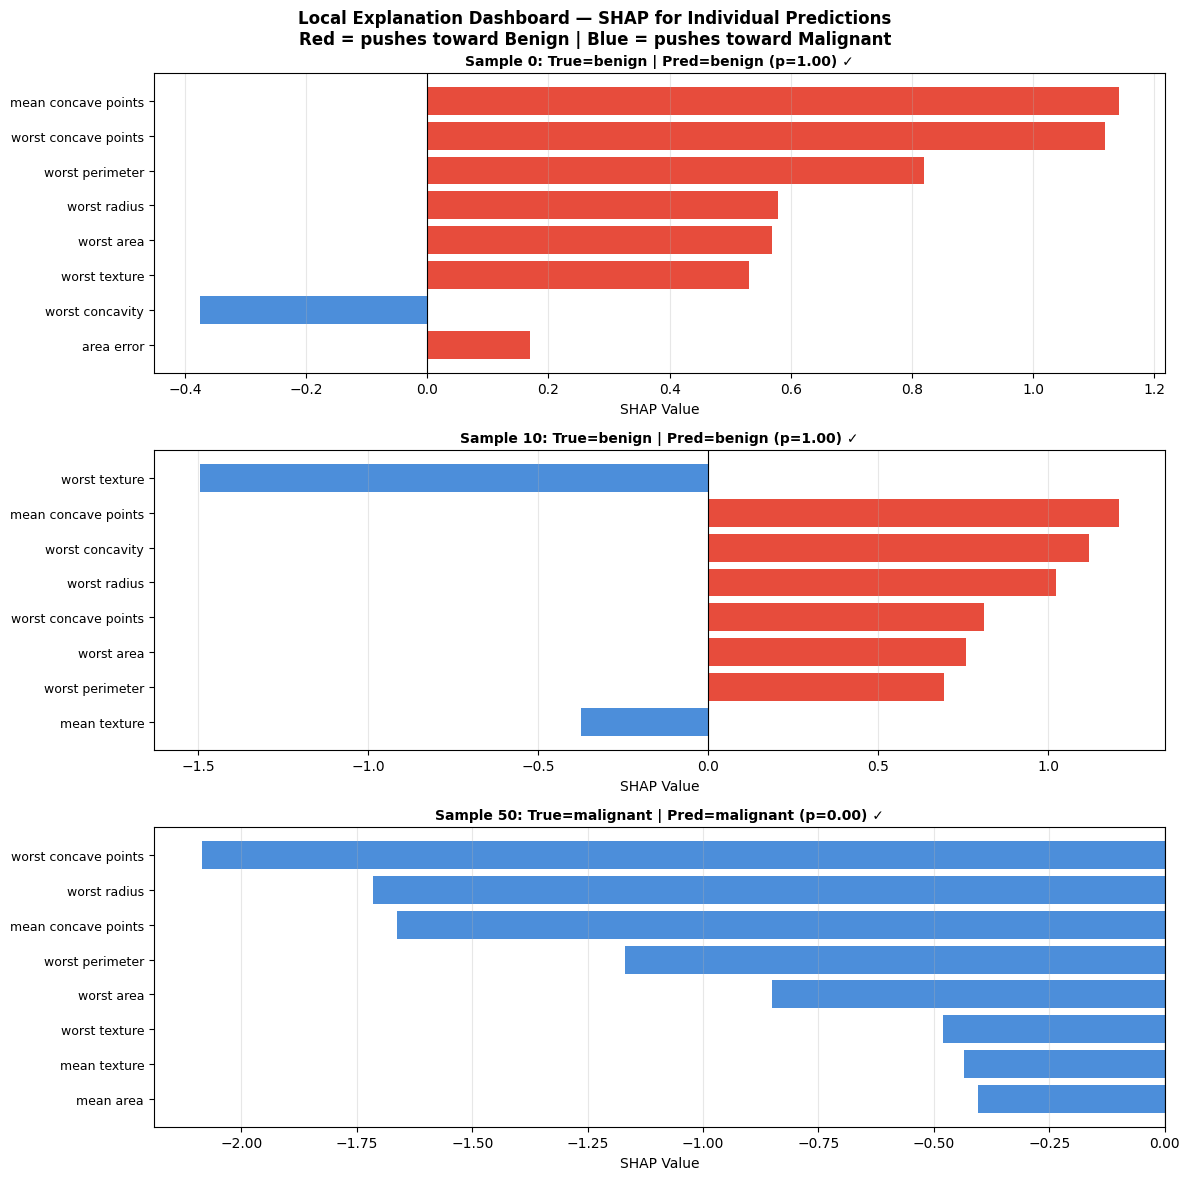

In [40]:
# ── Part 4: Full Interpretability Dashboard ────────────────
# Pick 3 diverse test samples to explain
sample_indices = [0, 10, 50]
fig, axes = plt.subplots(len(sample_indices), 1, figsize=(12, 4*len(sample_indices)))

for ax, idx in zip(axes, sample_indices):
    true_lbl  = data.target_names[yte[idx]]
    pred_lbl  = data.target_names[gbm.predict(Xte[idx:idx+1])[0]]
    prob      = gbm.predict_proba(Xte[idx:idx+1])[0, 1]

    # Top 8 SHAP values for this sample
    sv_sample = pd.Series(shap_values[idx], index=feat_names).reindex(
        pd.Series(shap_values[idx], index=feat_names).abs().sort_values(ascending=False).index
    )[:8]

    colors = ['#E74C3C' if v > 0 else '#4C8EDA' for v in sv_sample.values]
    ax.barh(range(len(sv_sample)), sv_sample.values[::-1],
            color=colors[::-1])
    ax.set_yticks(range(len(sv_sample)))
    ax.set_yticklabels(sv_sample.index[::-1], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP Value')
    correct = '✓' if true_lbl == pred_lbl else '✗'
    ax.set_title(f'Sample {idx}: True={true_lbl} | Pred={pred_lbl} (p={prob:.2f}) {correct}',
                  fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Local Explanation Dashboard — SHAP for Individual Predictions\n'
             'Red = pushes toward Benign | Blue = pushes toward Malignant',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Summary: Complete Reference Card

## 5.1 Imbalanced Data Handling

| Technique | What it Does | When to Use | Key Parameter |
|---|---|---|---|
| **SMOTE** | Creates synthetic minority samples | Tabular data, ratio >4:1, enough minority samples | `k_neighbors=5` |
| **Class Weights** | Penalizes minority class errors more | Any sklearn model, fast solution | `class_weight='balanced'` |
| **Threshold Tuning** | Adjusts decision cutoff | After training, optimize precision/recall tradeoff | `threshold` (default 0.5) |

```
Decision Guide:
  Ratio < 10:1  → Class weights (simple, effective)
  Ratio 10-100:1 → SMOTE + class weights
  Always         → Tune threshold for your use case
  Metric         → Use F1/AUC-ROC, NOT accuracy
```

## 5.2 Feature Engineering

| Technique | What it Does | When to Use |
|---|---|---|
| **Feature Selection** | Remove irrelevant/redundant features | >20 features, slow training, overfitting |
| **Correlation Handling** | Remove multicollinear features | \|r\| > 0.85 between features |
| **PCA** | Compress features into principal components | High dimensionality, correlated features |
| **Domain Features** | Create meaningful combinations | Always — biggest ROI |

## 5.4 Explainability

| Technique | Scope | Speed | Best For |
|---|---|---|---|
| **SHAP** | Global + Local | Medium-Fast (TreeSHAP) | Any model, gold standard |
| **Feature Importance** | Global | Fast | Quick inspection, tree models |
| **Permutation Importance** | Global | Slow | Model-agnostic, reliable |
| **PDP / ICE** | Global | Medium | Feature effect analysis |
| **Decision Tree viz** | Global | Instant | Fully interpretable rules |

```
Quick Rule:
  Need to explain to business → SHAP waterfall (per prediction)
  Need global feature ranking → SHAP bar/beeswarm
  Need feature effect shape   → PDP / SHAP dependence
  Need fast inspection        → sklearn feature_importances_
```